In [85]:
!pip install tensorflow scikit-learn



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [86]:
import keras
import tensorflow as tf
from sklearn.model_selection import train_test_split

In [87]:
(train_input, train_target), (test_input, test_target) = keras.datasets.fashion_mnist.load_data()

In [88]:
train_input.shape

(60000, 28, 28)

In [89]:
train_scaled = train_input.reshape(-1, 28, 28, 1) / 255.0
test_scaled = test_input.reshape(-1, 28, 28, 1) / 255.0

In [90]:
train_scaled.shape
# 애는 4차원이 됐는데 왜 이러냐?
# 합성곱 Conv 2D는 입력값으로 4차원 텐서를 요구
# 채널이 1(흑백)이라서 28 x 28 x1 이지만, 컬러는 reshape(-1, Height, Width, 3) R, G, B 3채널이다.

(60000, 28, 28, 1)

In [91]:
model = keras.Sequential()

In [92]:
model.add(keras.layers.Input(shape=(28, 28, 1))) #입력층

In [93]:
# Layer 1
model.add(keras.layers.Conv2D(32, 3, activation='relu', padding='same')) 
# 필터 갯수를 32개, 3X3 필터, ReLU, 패딩설정
# 출력 shape (28, 28, 32), 파라미터 수:(3*3*1+1)*32
model.add(keras.layers.MaxPool2D(2))
# 출력 shape (14, 14, 32), 파라미터수 : 0

<!-- 위의 Conv2D에서 입력과 출력의 값이 28로 같은 이유는 padding을 same으로 지정해서이다. -->

In [94]:
# Layer 2
model.add(keras.layers.Conv2D(64, 3, activation='relu', padding='same')) 
# 필터 갯수를 64개, 3X3 필터, ReLU, 패딩설정
# 출력 shape (14, 14, 64), 파라미터 수:(3*3*32+1)*64 = 18496개
model.add(keras.layers.MaxPool2D(2))
# 출력 shape (7, 7, 64), 파라미터수 : 0

# 입력층과 출력층의 모양
Input Shape:
A 4D tensor with shape:(batch_size, height, width, channels)
Output Shaep:
A 4D tensor with shape: (batch_size, new_height, new_width, filters)

# 다운샘플링
연산량을 줄이고, 속도를 늘리고, 추상화를 개념화시키기 위해, 해상도, 특징을 압축하고 요약하는 단계

In [95]:
# Full_Connected Layer
model.add(keras.layers.Flatten()) #출력 7*7*64= 3136 (batch, 3136)


In [96]:
model.add(keras.layers.Dense(100, activation="relu")) #파라미터 3136 * 100 + 100 = 313,700

In [97]:
#과적합을 피하기 위한 Dropout
model.add(keras.layers.Dropout(0.4))

In [98]:
# 출력층: 구별하고자 하는 분류개수만큼 (class) Unit 설정
model.add(keras.layers.Dense(10, activation="softmax")) #파라미터 100 * 10 + 10 =1,010개

In [99]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 100)            │       313,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 333,526 (1.27 MB)

 Trainable params: 333,526 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

In [100]:
# 모델 compile
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=["accuracy"], jit_compile=False)
#accuracy가 리스트로 되 있는 이유는 다른 항목도 집어넣을 수 있다는 뜻이다.

In [101]:
#콜백설정(checkpoint, early_stopping)
checkpoint = keras.callbacks.ModelCheckpoint('best-model.keras', save_best_only=True)
early_stopping = keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True)

In [102]:
history = model.fit(train_scaled, train_target, epochs=20, callbacks=[checkpoint, early_stopping], validation_split=0.2)
# validation_split은 이렇게 수치로 넣어도 되고, 직접 val_scaled로 나눠서 할 수도 있다. 정보를 확인하고 싶을 때!

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8113 - loss: 0.5257 - val_accuracy: 0.8786 - val_loss: 0.3370
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8782 - loss: 0.3424 - val_accuracy: 0.8914 - val_loss: 0.2806
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8947 - loss: 0.2925 - val_accuracy: 0.9085 - val_loss: 0.2491
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9063 - loss: 0.2602 - val_accuracy: 0.9146 - val_loss: 0.2450
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9134 - loss: 0.2342 - val_accuracy: 0.9143 - val_loss: 0.2275
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9202 - loss: 0.2162 - val_accuracy: 0.9168 - val_loss: 0.2326
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9268 - loss: 0.1953 - val_accuracy: 0.9175 - val_loss: 0.2311


In [103]:
history.history['loss']
history.history['val_loss']

[0.33696940541267395,
 0.2805839776992798,
 0.24907541275024414,
 0.24496003985404968,
 0.2275344431400299,
 0.23260053992271423,
 0.231138676404953]

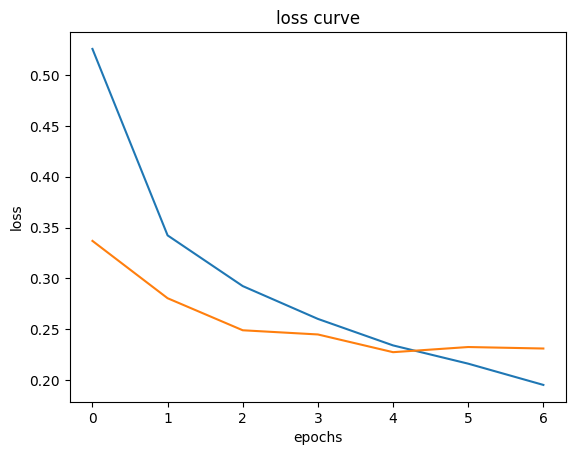

In [104]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel("epochs")
plt.ylabel('loss')
plt.title('loss curve')
plt.show()

In [105]:
# train_test로 나눠야 하는데,,,


# 테스트 평가
model.evaluate(test_scaled, test_target)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9115 - loss: 0.2513


[0.25131091475486755, 0.9114999771118164]

In [106]:
#예측
model.predict(test_scaled[0:1])
#이렇게 보면 뭐가 높은지 모르겠다... 넘파이를 쓰자!!

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


array([[1.5269022e-07, 4.2707582e-10, 2.6573716e-08, 2.5772187e-09,
        1.5056111e-09, 8.7237087e-05, 1.8078281e-07, 2.0902476e-04,
        2.3303633e-08, 9.9970335e-01]], dtype=float32)

In [107]:
import numpy as np
preds = model.predict(test_scaled[0:1])
np.argmax(preds) #9번 당선~~~~

classes = ['티셔츠', '바지', '스웨터', '드레스', '코트',
           '샌달', '셔츠', '스니커즈', '가방', '앵클 부츠']

classes[np.argmax(preds)] #첫번째 사진의 예측값은 앵클 부츠!


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


'앵클 부츠'

C:\Users\kim\AppData\Local\Temp\ipykernel_13680\4094472927.py:5: UserWarning: Glyph 54000 (\N{HANGUL SYLLABLE TI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kim\AppData\Local\Temp\ipykernel_13680\4094472927.py:5: UserWarning: Glyph 49492 (\N{HANGUL SYLLABLE SYEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kim\AppData\Local\Temp\ipykernel_13680\4094472927.py:5: UserWarning: Glyph 52768 (\N{HANGUL SYLLABLE CEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kim\AppData\Local\Temp\ipykernel_13680\4094472927.py:5: UserWarning: Glyph 48148 (\N{HANGUL SYLLABLE BA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kim\AppData\Local\Temp\ipykernel_13680\4094472927.py:5: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kim\AppData\Local\Temp\ipykernel_13680\4094472927.py:5: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu San

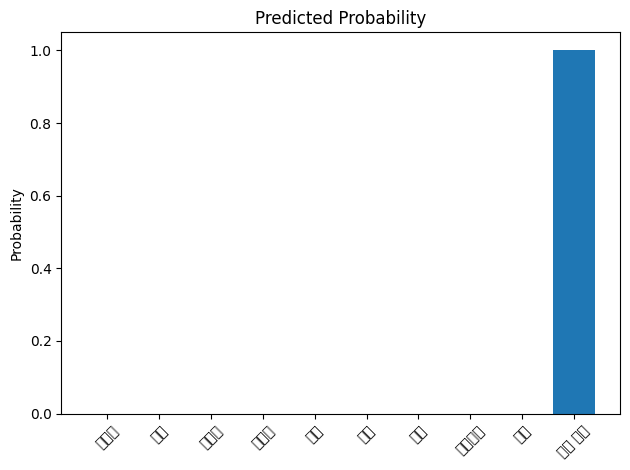

In [108]:
plt.bar(range(1, 11), preds[0])
plt.xticks(range(1, 11), classes, rotation=45)
plt.ylabel('Probability')
plt.title('Predicted Probability')
plt.tight_layout()
plt.show()

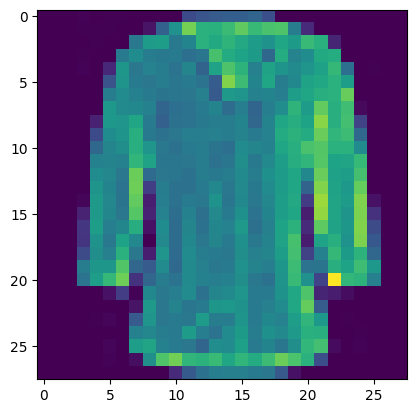

In [109]:
#맞는지 확인하기
plt.imshow(test_scaled[4])
plt.show()

In [110]:
test_scaled.shape
predict_plot(699)

NameError: name 'predict_plot' is not defined